# Repressilator

$$
\lambda CI \dashv LacI \dashv TetR \dashv \lambda CI
$$

Each Component has an mRNA and a Protein, hence the equations are:

$$\begin{aligned}
\frac{dm_i}{dt} &= -m_i + \frac{\alpha}{1+P_j^n} + \alpha_0 \\[1.5ex]
\frac{dP_i}{dt} &= -\beta (P_i - m_i)
\end{aligned}$$
 
Where: <br>
i = {LCI, LacI, TetR}, j = {TetR, LCI, LacI} <br>
and: <br>
m = concentration of mRNA <br>
P = concentration of protein <br>
$\alpha$ = max production rate <br>
$\alpha_0$ = basal transcription rate <br>
$n$ = hill coeficient <br>
$\beta$ = protein decay

# GFP as observable

$$
R_n G \xrightleftharpoons[k_e]{k_d} nR + G \xrightarrow{k_g} G + mRNA \xrightarrow{k_m} G + mRNA + P
$$

Where R is $P_{TetR}$ and P is GFP. mRNA decays at rate $d_1$ and P at rate $d_2$. <br>

Hence, the equations are: <br>

$$\begin{aligned}
\frac{dRNA}{dt} &= \frac{\alpha_{GFP}}{1 + K_R R^n} - d_1 mRNA\\
\frac{dP}{dt} &= k_m mRNA - d_2 P\\
\end{aligned}$$


# Import Libraries

In [2]:
import jax
import jax.numpy as jnp
import diffrax
import equinox as eqx
import lineax as lx
import optimistix as optx
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import random
import time
import os 
from tkinter import simpledialog
from operator import contains
from tkinter.filedialog import askdirectory
import tkinter as tk
from ipywidgets import interact, widgets, fixed, interactive, HBox, Layout, VBox
import pickle
import matplotlib as mpl
import pandas as pd

In [3]:
from Repressilator import Repressilator

# Initial Play with Repressilator

In [4]:
Repressilator((0, 50), 500, [], []).play()

Output()

# Simulate Repressilator CPU

### Simulate Original Model (only regulatory components)

In [12]:
np.random.seed(42)

N = 100 # Number of samples (theta and y0 together)

thsb = np.zeros((N,4)) # Array for parameters
y0sb = np.zeros((N,6)) # Array for y0

#     alpha_0  alpha   beta   n  
meT = [1e-1,    70,    0.3,   2]
sdT = [1e-3,    10,    1e-2,  1e-1]

#     rnaI  rnaL  rnaT  pI   pL    pT 
meY = [40,  20,   6,    40,  15,   40]
sdY = [4,   2,    0.6,  4,   1.5,  4]

for i in range(np.shape(thsb)[1]):
    thsb[::,i] = abs(np.random.normal(loc=meT[i], scale=sdT[i], size=N))

for i in range(np.shape(y0sb)[1]):
    y0sb[::,i] = abs(np.random.normal(loc=meY[i], scale=sdY[i], size=N))

In [9]:
Repressilator((0, 50), 500, thsb, y0sb).sim()

array([[[33.62228936, 21.8523551 ,  6.45419317, 37.90910792,
         16.40742571, 41.47469324],
        [30.46101871, 19.80324058,  5.87856094, 37.723464  ,
         16.5327022 , 40.41826785],
        [27.57811789, 17.93448746,  5.35335846, 37.46023338,
         16.60082761, 39.37626516],
        ...,
        [ 6.36462017,  0.40845266, 10.60960085, 13.7732448 ,
          1.73265481,  4.63357079],
        [ 6.02720023,  0.41431007, 11.00725637, 13.54603274,
          1.69306786,  4.81854763],
        [ 5.70310147,  0.42076087, 11.41291274, 13.31581302,
          1.65485123,  5.01003948]],

       [[37.60249991, 23.81883328,  5.44670081, 44.1960369 ,
         14.22593291, 38.42664475],
        [34.06615275, 21.58282189,  4.97646107, 43.9330006 ,
         14.47334064, 37.42655499],
        [30.84136427, 19.54369369,  4.54676089, 43.58411032,
         14.65483126, 36.44216076],
        ...,
        [24.08221227,  0.29440277,  3.77242482, 23.64619866,
          3.41365592,  1.71725719],
  

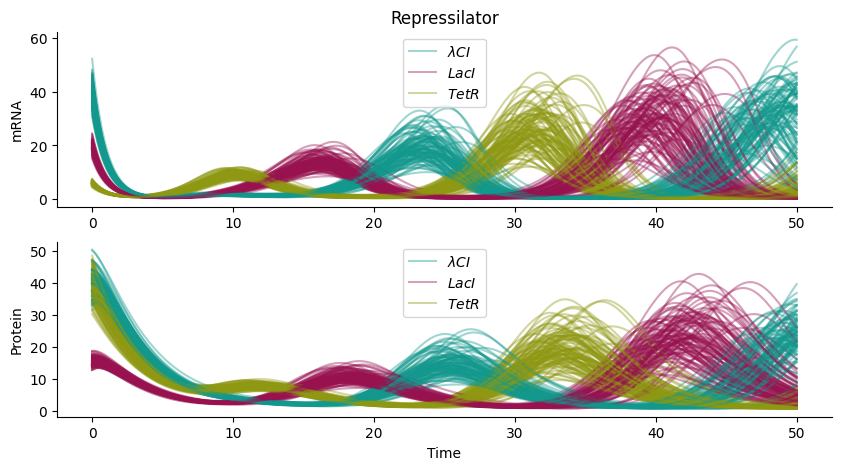

In [10]:
Repressilator((0, 50), 500, thsb, y0sb).plot()

### Simulate Expanded Model (with GFP)

In [14]:
np.random.seed(42)

N = 100 # Number of samples (theta and y0 together)

thsb2 = np.zeros((N,10)) # Array for parameters
y0sb2 = np.zeros((N,8)) # Array for y0

#     alpha_0  alpha   beta   n     alpha_G   kR     kM     n2     d1     d2
meT2 = [1e-1,    70,    0.3,   2,     10,      1,     0.4,   1,     1,     1e-1]
sdT2 = [1e-3,    10,    1e-2,  1e-1,  3,       1e-1,  1e-2,  1e-1,  1e-1,  1e-3]

#     rnaI  rnaL  rnaT  pI   pL    pT   rnaG  pG
meY2 = [40,  20,   6,    40,  15,   40,  2,    0]
sdY2 = [4,   2,    0.6,  4,   1.5,  4,   0.5,  1]

for i in range(np.shape(thsb2)[1]):
    thsb2[::,i] = abs(np.random.normal(loc=meT2[i], scale=sdT2[i], size=N))

for i in range(np.shape(y0sb2)[1]):
    y0sb2[::,i] = abs(np.random.normal(loc=meY2[i], scale=sdY2[i], size=N))

In [15]:
Repressilator((0, 50), 500, thsb2, y0sb2).sim()

array([[[4.55974217e+01, 2.19960202e+01, 6.07513470e+00, ...,
         4.31134443e+01, 1.90855178e+00, 3.50630099e-01],
        [4.12928178e+01, 1.99275847e+01, 5.54480625e+00, ...,
         4.19970808e+01, 1.72442508e+00, 4.20281246e-01],
        [3.73726686e+01, 1.80437686e+01, 5.06098666e+00, ...,
         4.08981129e+01, 1.55847255e+00, 4.82659322e-01],
        ...,
        [1.48576606e+01, 3.35432875e-01, 5.35608834e+00, ...,
         2.35911259e+00, 1.66163848e+00, 5.52881895e+00],
        [1.42836886e+01, 3.33228795e-01, 5.60216444e+00, ...,
         2.45257648e+00, 1.63013093e+00, 5.54037286e+00],
        [1.37142950e+01, 3.31500752e-01, 5.85799141e+00, ...,
         2.55076534e+00, 1.59821198e+00, 5.55051586e+00]],

       [[4.36985347e+01, 1.42074892e+01, 5.74235668e+00, ...,
         3.77952571e+01, 2.68743821e+00, 4.89187130e-01],
        [3.95779110e+01, 1.28763477e+01, 5.23746564e+00, ...,
         3.68221068e+01, 2.45736739e+00, 5.83698082e-01],
        [3.58240135e+01, 

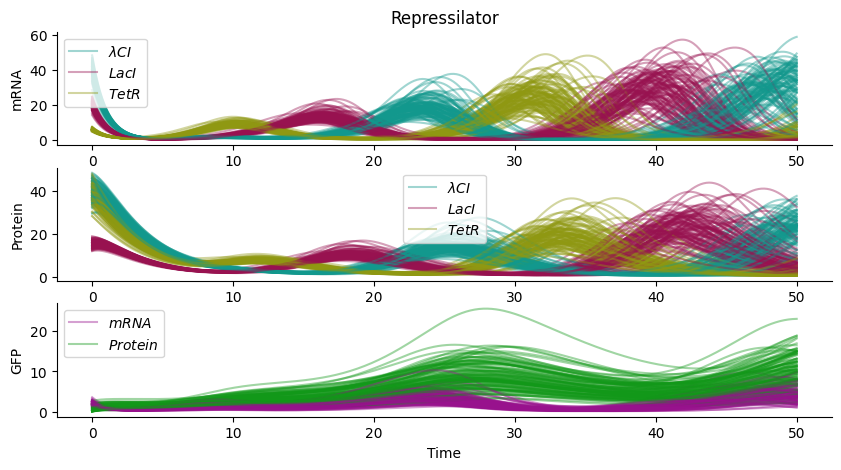

In [16]:
Repressilator((0, 50), 500, thsb2, y0sb2).plot()